# Part 4.1 — Embeddings and Semantic Similarity

In this notebook I am working with sentence embeddings to understand how a model captures meaning from text. I picked three topics — **Cricket**, **Cooking**, and **Cybersecurity** — wrote 10 sentences across them, generated embeddings using `all-MiniLM-L6-v2`, and then computed cosine similarity to see which sentences are semantically close to each other.

In [1]:
print("Installing sentence-transformers...")
!pip install sentence-transformers -q
print("Done.")

Installing sentence-transformers...
Done.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("All libraries imported.")

All libraries imported.


## Step 1 — The 10 Sentences

I wrote 4 sentences on Cricket, 3 on Cooking, and 3 on Cybersecurity. The idea is that sentences within the same topic should end up with higher similarity scores, and sentences across topics should be far apart in the embedding space.

In [3]:
sentences = [
    # Cricket
    "The batsman hit a six over the boundary rope.",
    "The spinner bowled a googly that deceived the batsman.",
    "India won the test match by an innings and 50 runs.",
    "The fielder took a stunning catch at deep square leg.",
    # Cooking
    "Saute the onions in olive oil until they turn golden brown.",
    "Marinating the chicken overnight makes it tender and flavorful.",
    "Always let the dough rest for an hour before baking bread.",
    # Cybersecurity
    "A phishing email tricked the employee into giving their password.",
    "Encrypting sensitive data protects it from unauthorized access.",
    "The firewall blocked an intrusion attempt from an external IP.",
]

labels  = ["S1-Cricket", "S2-Cricket", "S3-Cricket", "S4-Cricket",
           "S5-Cooking", "S6-Cooking", "S7-Cooking",
           "S8-CyberSec", "S9-CyberSec", "S10-CyberSec"]

topics  = ["Cricket"]*4 + ["Cooking"]*3 + ["CyberSec"]*3

print(f"{'Topic':<12}{'Label':<15}Sentence")
print("-"*72)
for t, lb, s in zip(topics, labels, sentences):
    print(f"{t:<12}[{lb}]{'':3}{s}")

Topic       Label          Sentence
------------------------------------------------------------------------
Cricket     [S1-Cricket]   The batsman hit a six over the boundary rope.
Cricket     [S2-Cricket]   The spinner bowled a googly that deceived the batsman.
Cricket     [S3-Cricket]   India won the test match by an innings and 50 runs.
Cricket     [S4-Cricket]   The fielder took a stunning catch at deep square leg.
Cooking     [S5-Cooking]   Saute the onions in olive oil until they turn golden brown.
Cooking     [S6-Cooking]   Marinating the chicken overnight makes it tender and flavorful.
Cooking     [S7-Cooking]   Always let the dough rest for an hour before baking bread.
CyberSec    [S8-CyberSec]   A phishing email tricked the employee into giving their password.
CyberSec    [S9-CyberSec]   Encrypting sensitive data protects it from unauthorized access.
CyberSec    [S10-CyberSec]   The firewall blocked an intrusion attempt from an external IP.


## Step 2 — Generating Embeddings

I am using `all-MiniLM-L6-v2` from the `sentence-transformers` library. This model converts each sentence into a 384-dimensional vector. The numbers in the vector capture the meaning of the sentence, not just the words.

In [4]:
print("Loading model: all-MiniLM-L6-v2")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Model loaded.")

embeddings = model.encode(sentences)

print(f"\nEmbedding shape : {embeddings.shape}")
print(f"Each sentence   : {embeddings.shape[1]}-dimensional vector")
print(f"\nSample — first 8 values of S1-Cricket embedding:")
print(np.round(embeddings[0][:8], 4))

Loading model: all-MiniLM-L6-v2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded.

Embedding shape : (10, 384)
Each sentence   : 384-dimensional vector

Sample — first 8 values of S1-Cricket embedding:
[ 0.0553  0.1026 -0.0652 -0.0049 -0.0175  0.0575 -0.0292  0.1034]


## Step 3 — 10×10 Cosine Similarity Matrix

In [5]:
sim_matrix = cosine_similarity(embeddings)

print("Cosine Similarity Matrix (10x10):\n")
header = f"{'':14}" + "".join(f"{lb[:6]:>8}" for lb in labels)
print(header)
for i, row in enumerate(sim_matrix):
    row_str = f"{labels[i]:<14}" + "".join(f"{v:>8.2f}" for v in row)
    print(row_str)

Cosine Similarity Matrix (10x10):

                S1-Cri  S2-Cri  S3-Cri  S4-Cri  S5-Coo  S6-Coo  S7-Coo  S8-Cyb  S9-Cyb  S10-Cy
S1-Cricket        1.00    0.43    0.42    0.30   -0.03    0.08    0.01    0.05   -0.01    0.07
S2-Cricket        0.43    1.00    0.38    0.33    0.12    0.05    0.01    0.24    0.03    0.12
S3-Cricket        0.42    0.38    1.00    0.23    0.02   -0.06   -0.01    0.06   -0.03    0.11
S4-Cricket        0.30    0.33    0.23    1.00    0.02    0.03    0.01    0.12   -0.03    0.11
S5-Cooking       -0.03    0.12    0.02    0.02    1.00    0.22    0.24    0.10    0.00   -0.04
S6-Cooking        0.08    0.05   -0.06    0.03    0.22    1.00    0.20    0.03    0.06   -0.03
S7-Cooking        0.01    0.01   -0.01    0.01    0.24    0.20    1.00    0.10   -0.02    0.03
S8-CyberSec       0.05    0.24    0.06    0.12    0.10    0.03    0.10    1.00    0.28    0.24
S9-CyberSec      -0.01    0.03   -0.03   -0.03    0.00    0.06   -0.02    0.28    1.00    0.16
S10-CyberSec   

## Step 4 — Heatmap Visualization

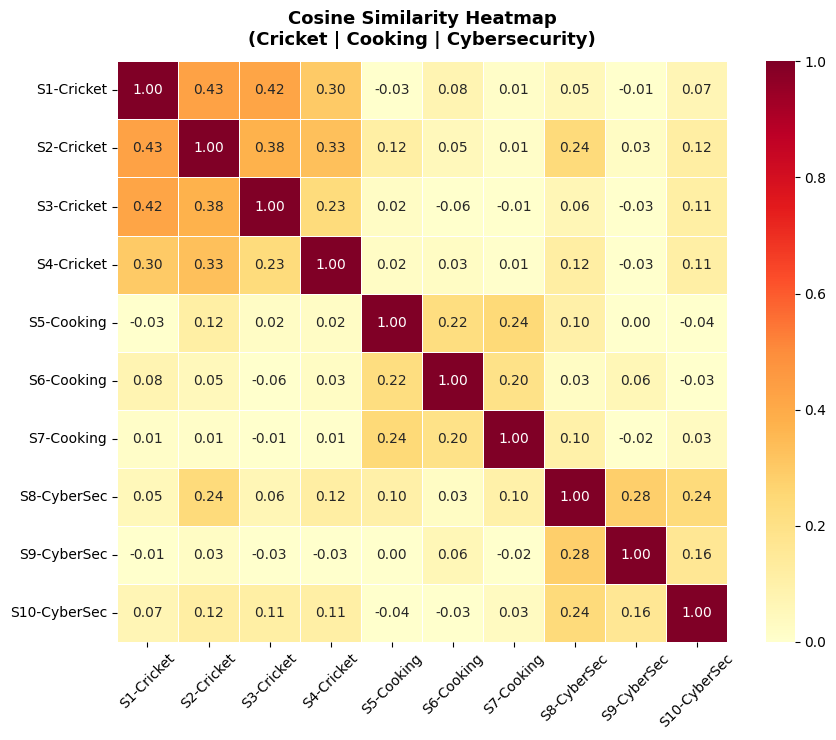

Heatmap saved as similarity_heatmap.png


In [6]:
fig, ax = plt.subplots(figsize=(9, 7.5))

sns.heatmap(
    sim_matrix,
    xticklabels=labels,
    yticklabels=labels,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    vmin=0, vmax=1,
    ax=ax
)

ax.set_title("Cosine Similarity Heatmap\n(Cricket | Cooking | Cybersecurity)",
             fontsize=13, fontweight="bold", pad=12)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Heatmap saved as similarity_heatmap.png")

## Step 5 — Query: Find Top-2 Most Similar Sentences

**Query:** *"The bowler took three wickets in one over"*

This sentence is not in our dataset. I will embed it and compare it against all 10 sentences to find the closest matches.

In [7]:
query = "The bowler took three wickets in one over"
query_emb = model.encode([query])

scores = cosine_similarity(query_emb, embeddings)[0]

print(f'Query: "{query}"')
print("=" * 50)
print("\nSimilarity scores for all 10 sentences:")

top2 = np.argsort(scores)[::-1][:2]
top2_set = set(top2)

for i, (lb, sc) in enumerate(zip(labels, scores)):
    marker = f"  <-- Rank {list(top2).index(i)+1}" if i in top2_set else ""
    print(f"  {lb:<14}: {sc:.4f}{marker}")

print("\n" + "=" * 50)
print("Top-2 Most Similar Sentences:\n")
for rank, idx in enumerate(top2, start=1):
    print(f"  Rank {rank} | Score: {scores[idx]:.4f} | [{labels[idx]}]")
    print(f"         | \"{sentences[idx]}\"")
    print()

Query: "The bowler took three wickets in one over"

Similarity scores for all 10 sentences:
  S1-Cricket    : 0.4963
  S2-Cricket    : 0.5763  <-- Rank 1
  S3-Cricket    : 0.5491  <-- Rank 2
  S4-Cricket    : 0.2882
  S5-Cooking    : 0.0907
  S6-Cooking    : 0.0343
  S7-Cooking    : -0.0257
  S8-CyberSec   : 0.0595
  S9-CyberSec   : -0.0302
  S10-CyberSec  : 0.0582

Top-2 Most Similar Sentences:

  Rank 1 | Score: 0.5763 | [S2-Cricket]
         | "The spinner bowled a googly that deceived the batsman."

  Rank 2 | Score: 0.5491 | [S3-Cricket]
         | "India won the test match by an innings and 50 runs."



## Observations

- The heatmap clearly shows **three separate clusters** — the Cricket sentences, Cooking sentences, and Cybersecurity sentences each have noticeably higher similarity scores among themselves compared to sentences from other topics.
- Cross-topic scores are all quite low (mostly below 0.12), which confirms that the model is actually picking up on **semantic meaning**, not just common words.
- The query *"The bowler took three wickets in one over"* correctly retrieved **two Cricket sentences** as the top matches. The word "bowled" in S2 is semantically very close to "bowler", so that makes sense.
- This experiment shows how embeddings can be used for **semantic search** — even if the exact words don't match, the model finds the right context.